## Project 1 - Exploratory Data Analysis Notebook

## Used Car Data from Craigslist in the US 

In [295]:
# Load here the libraries you are going to need.
# You need to run this before using any command from these libraries.
#import sys
#assert sys.version_info >= (3, 7)
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

## Introduction

in this Notebook, I will do the following:
* Get the data I will use to perform the analysis;
* Check and handle missing values (if any);
* Compute simple statistics on single variables;
* Check and study outliers;
* Draw Basic Plots
* Relate price, odometer and year
* Write a Conclusion about my findings and possible relations of variables.

## Getting the Data and Presenting it
For this Exploratory Data Analysis, I will be using the dataset "Used Cars Dataset - Vehicles from Craigslist within the US" from Kaggle: \
https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data \
This dataset contains a lot of information about used vehicle sales in the US. \
The data from this set was collected in 2021 and has not been updated since.

I chose the used vehicles on craigslist in the US because I am interested in how car prices can change according to different aspects. I am particularly interested in the cars' mileage, age and price. I also chose this set and category since cars have a lot of data and also some numerical values especially in the variables that I am interested in. This makes it easier to compute and find correlations. \
The dataset contains over 400,000 listings, with features such as price, year, odometer, condition, manufacturer, and more. These columns provide both numerical and categorical data, which is suitable for analysis. \
The dataset is not cleaned yet and it has a lot of entries, so I first will have to go through thorough cleaning. 

## Loading the Data

In [296]:
car = pd.read_csv('vehicles.csv') 

## Exploring the Dataset Structure

In [297]:
car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [298]:
car.shape

(426880, 26)

In [299]:
car.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [300]:
car.tail()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
426875,7301591192,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,...,NaN,sedan,NaN,https://images.craigslist.org/00o0o_iiraFnHg8q...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:31-0600
426876,7301591187,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,...,NaN,sedan,red,https://images.craigslist.org/00x0x_15sbgnxCIS...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:29-0600
426877,7301591147,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,...,NaN,hatchback,white,https://images.craigslist.org/00L0L_farM7bxnxR...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:17-0600
426878,7301591140,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,...,NaN,sedan,silver,https://images.craigslist.org/00z0z_bKnIVGLkDT...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:11-0600
426879,7301591129,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2019.0,bmw,4 series 430i gran coupe,good,NaN,...,NaN,coupe,NaN,https://images.craigslist.org/00Y0Y_lEUocjyRxa...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:07-0600


## Initial findings about the structure of the data
* It has 26 columns and 426879 lines. Each column title is a variable. Thus the data are organized in the wide format.
* 7 variables are numerical ones (float64 and int64) and 19 variables are categorical, which means they are Words rather than numbers.
* The following variables have Null Values which indicate potential missing Data: \
    year: 426880 - 425675 = 1205 \
    manufacturer: 426880 - 409234 = 17646 \
    model: 426880 - 421603 = 5277 \
    condition: 426880 - 252776 = 174104 \
    cylinders: 426880 - 249202 = 177678 \
    fuel: 426880 - 423867 = 3013 \
    odometer: 426880 - 422480 = 4400 \
    title_status: 426880 - 418638 = 8242 \
    transmission: 426880 - 424324 = 2556 \
    VIN: 426880 - 265838 = 161042 \
    drive: 426880 - 296313 = 130567 \
    size: 426880 - 120519 = 306369 \
    type: 426880 - 334022 = 92858 \
    paint_color: 426880 - 296677 = 130203 \
    image_url: 426880 - 426812 = 68 \
    description: 426880 - 426810 = 70 \
    lat: 426880 - 420331 = 6549 \
    long: 426880 - 420331 = 6549 \
    posting_date: 426880 - 426812 = 68 \

    

* What looks intersting here is that the variable county has 0 non-null variables which seems odd. This has to be investigated further and there might be adjustments I have to make to use the data. 
* Although 7 variables are numeric, their units, ranges and what they express are different and most of the data is in String format.
* There are lat/lon variables, indicating geographical location. This suggests that, maybe, the use of maps here will be useful.
* There are some variables that are completely unrelated to the analysis I want to do, so removing the attribute might be a good solution. The attributes to remove include among others: URL, posting_date and ID.
* I also saw that the year is stated as a float, when an Integer makes more sense, so I will have to convert that. 

## Some questions I want to answer
* Are cars with higher mileage cheaper?
* Are older cars cheaper than newer ones? 
* Are age and mileage of the car related?

# Check Missing Data

In [301]:
car.isna().any() # Check for nan, na and none types.

id              False
url             False
region          False
region_url      False
price           False
year             True
manufacturer     True
model            True
condition        True
cylinders        True
fuel             True
odometer         True
title_status     True
transmission     True
VIN              True
drive            True
size             True
type             True
paint_color      True
image_url        True
description      True
county           True
state           False
lat              True
long             True
posting_date     True
dtype: bool

### Conclusion
This implies that there are a lot of missing data like I already saw in the initial analysis above. \
For some of the totally unrelated data to my analysis, I will remove the whole category. \
For the other categories, I will explore a bit more and then decide whether to just remove the faulty / missing data or to replace it with the median or mean.\
For non-numerical values, I might consider replacing faulty / missing data with "unknown" if the percentage of faulty / missing data is too high

# Remove totally unrelated and useless categories
Since there are some unrelated and unimportant categories in this dataset that are not helpful for the questions I want to answer, I will remove them now. \
The categories to remove are the following:
* ID
* URL
* Region URL
* Image URL
* description
* Posting date
* VIN
* drive
* region since we already have state. Region is too specific and irrelevant
* lat and long are really not important in this exploration
* paint color is very unrelated to the price

First, let's check on that suspicious behaviour of "county" by seeing what unique values it takes:

In [302]:
car['county'].unique()

array([nan])

This means that the whole column really is only consisting of null values. This means that I can also safely remove it

In [303]:
car2 = car.drop(['id', 'url', 'region_url', 'image_url', 'description', 'posting_date', 'VIN', 'drive', 'region', 'county', 'lat', 'long', 'paint_color'], axis=1)

Now, let's see the new shape of the data.

In [304]:
car2.shape
car2.columns
car2.head()
car2.tail()

,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,size,type,state
426875,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,NaN,sedan,wy
426876,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,12029.0,clean,other,NaN,sedan,wy
426877,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,clean,other,NaN,hatchback,wy
426878,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,NaN,sedan,wy
426879,30590,2019.0,bmw,4 series 430i gran coupe,good,NaN,gas,22716.0,clean,other,NaN,coupe,wy


The columns decreased from 26 to 14, so the removal was successful. \
The dataset is looking a lot cleaner already. 

# Data Cleaning

Let's check the details of faulty / missing data of the year of the car

In [305]:
bad_data_year = car2[car2.year.isna()]

In [306]:
bad_data_year.shape

(1205, 13)

In [307]:
bad_data_year

,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,size,type,state
0,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc
...,...,...,...,...,...,...,...,...,...,...,...,...,...
414161,59697,NaN,NaN,olet Silverado 3500HD CC,NaN,8 cylinders,gas,0.0,clean,automatic,NaN,pickup,wv
414162,90877,NaN,NaN,olet Silverado MD,NaN,8 cylinders,diesel,0.0,clean,automatic,NaN,pickup,wv
423519,16990,NaN,NaN,HR-V,NaN,4 cylinders,gas,60424.0,NaN,manual,NaN,SUV,wi
423528,19995,NaN,NaN,Renegade,NaN,4 cylinders,gas,9217.0,NaN,automatic,NaN,SUV,wi


This means that there are 1205 data points that are missing the entry for the year. \
But my whole dataset consists of over 400000 entries, So the missing data here are only around 0.3% of the whole data which is insignificant. \
Because of this, it is save to delete the data. \
Additionally, from the preview I saw that those data points are also missing a lot of other entries, which is even more reason to exclude those datapoints.

In [308]:
car3 = car2[~car2.year.isna()]
car3.shape

(425675, 13)

In [309]:
car3.isna().any() # Check for nan, na and none types again.

price           False
year            False
manufacturer     True
model            True
condition        True
cylinders        True
fuel             True
odometer         True
title_status     True
transmission     True
size             True
type             True
state           False
dtype: bool

Now, the year is not missing any data anymore and I can continue working on the other values. 

Checking manufacturer variable:

In [310]:
bad_data_manufacturer = car3[car3.manufacturer.isna()]
bad_data_manufacturer.shape


(16447, 13)

In [311]:
bad_data_manufacturer

,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,size,type,state
97,15990,2016.0,NaN,Scion iM Hatchback 4D,good,NaN,gas,29652.0,clean,other,NaN,hatchback,al
122,6800,2005.0,NaN,blue bird bus,excellent,6 cylinders,diesel,180000.0,clean,automatic,full-size,bus,al
135,14990,2016.0,NaN,Scion iM Hatchback 4D,good,NaN,gas,65203.0,clean,other,NaN,hatchback,al
137,2500,1966.0,NaN,1966 C-30 1 ton,good,6 cylinders,gas,47000.0,clean,manual,full-size,pickup,al
155,8990,2013.0,NaN,smart fortwo Passion Hatchback,good,NaN,gas,59072.0,clean,automatic,NaN,coupe,al
...,...,...,...,...,...,...,...,...,...,...,...,...,...
426843,21999,2017.0,NaN,2017,NaN,NaN,gas,51000.0,clean,automatic,NaN,NaN,wy
426846,41999,2015.0,NaN,2015,NaN,NaN,gas,126000.0,clean,automatic,NaN,NaN,wy
426862,27590,2018.0,NaN,Genesis G80 3.8 Sedan 4D,good,6 cylinders,gas,36138.0,clean,other,NaN,sedan,wy
426863,25590,2017.0,NaN,Genesis G80 3.8 Sedan 4D,good,6 cylinders,gas,37608.0,clean,automatic,NaN,sedan,wy


Since none of my research questions depend on the manufacturer at all, and the missing entries for such are 16447 out of 426879 which is around 3.85% of the whole data, it is quite insignificant. Since I can not really use a mean or median since it is a String and not a numerical value, it makes even more sense to drop it.
I could use the model to predict the manufacturer, but this is too advanced to do yet, I would need another MLM to do that or have a database I would scavenge.

In [312]:
car3 = car3[~car3.manufacturer.isna()]
car3.shape

(409228, 13)

In [313]:
car3.isna().any() # Check for nan, na and none types again.

price           False
year            False
manufacturer    False
model            True
condition        True
cylinders        True
fuel             True
odometer         True
title_status     True
transmission     True
size             True
type             True
state           False
dtype: bool

Checking the model: 

In [314]:
bad_data_model = car3[car3.model.isna()]
bad_data_model.shape

(5208, 13)

This value here is even smaller than for the previous ones, so I can remove it savely since there is also no mean or median I could use.

In [315]:
car3 = car3[~car3.model.isna()]
car3.shape
car3.isna().any() # Check for nan, na and none types again.

price           False
year            False
manufacturer    False
model           False
condition        True
cylinders        True
fuel             True
odometer         True
title_status     True
transmission     True
size             True
type             True
state           False
dtype: bool

Checking the condition:

In [316]:
bad_data_condition= car3[car3.condition.isna()]
bad_data_condition.shape

(164342, 13)

In [317]:
car3['condition'].unique()

array(['good', 'excellent', 'fair', 'like new', 'new', nan, 'salvage'],
      dtype=object)

This is a lot of data.
I can not exclude it, especially since it is very important for the price (my prediction for now, I will confirm this later) \
To avoid manipulating the data and making wrong analysis by deleting all the nan data, I will replace all nan with "unknown".

In [318]:
car4 = car3.copy()
car4['condition'] = car3['condition'].fillna('unknown')


In [319]:
car4.isna().any() # Check for nan, na and none types again.

price           False
year            False
manufacturer    False
model           False
condition       False
cylinders        True
fuel             True
odometer         True
title_status     True
transmission     True
size             True
type             True
state           False
dtype: bool

For the cylinders, I will convert the String type (it says "6 cylinders" instead of just the number 6) to an Integer. \
This allows me to find the median and then replace nan with the median.
I am using the median rather than the mean because cylinders have to be an integer and not a float. 

In [320]:
# This function I had to look up.
car4['cylinders'] = car4['cylinders'].str.extract('(\d+)').astype('float').astype('Int64')


In [321]:
bad_data_cylinders = car4[car4.cylinders.isna()]
bad_data_cylinders.shape

(167857, 13)

Lets find the data for cylinders now

In [322]:
car_cylinder_mean = car4['cylinders'].mean()
car_cylinder_median = car4['cylinders'].median()
print(car_cylinder_mean)
print(car_cylinder_median)

5.957152475197216
6.0


This proves my assumption to use the median rather than the mean. Both are actually basically the same, but the median is a whole number which makes more sense for cylinders since there are no 5.957 cylinders.

Now, I will replace all nan for cylinders with the median

In [323]:
car5 = car4.copy() # If you do not copy it will just create an alias to hs.
car5['cylinders'] = car5['cylinders'].fillna(car_cylinder_median)

In [324]:
car5.isna().any() # Check for nan, na and none types again.

price           False
year            False
manufacturer    False
model           False
condition       False
cylinders       False
fuel             True
odometer         True
title_status     True
transmission     True
size             True
type             True
state           False
dtype: bool

The data is strarting to look a lot cleaner and more useable than in the beginning. 

Checking the odometer (Mileage):

In [325]:
bad_data_odometer = car5[car5.odometer.isna()]
bad_data_odometer.shape

(4137, 13)

Insignificant percentage -> We can safely remove 

In [326]:
car5 = car5[~car5.odometer.isna()]
car5.shape
car5.isna().any() # Check for nan, na and none types again.

price           False
year            False
manufacturer    False
model           False
condition       False
cylinders       False
fuel             True
odometer        False
title_status     True
transmission     True
size             True
type             True
state           False
dtype: bool

Checking the fuel type:

In [327]:
bad_data_fuel = car5[car5.fuel.isna()]
bad_data_fuel.shape

(2009, 13)

remove the nan fuel entries since the percentage is also very small. 

In [328]:
car5 = car5[~car5.fuel.isna()]
car5.shape
car5.isna().any() # Check for nan, na and none types again.

price           False
year            False
manufacturer    False
model           False
condition       False
cylinders       False
fuel            False
odometer        False
title_status     True
transmission     True
size             True
type             True
state           False
dtype: bool

Checking what "Title Status" is about and if I can fill the faulty / missing data with a mean or median or if i should remove them or fill it with "unknown".

In [329]:
car5['title_status'].unique()

array(['clean', 'rebuilt', 'lien', nan, 'salvage', 'missing',
       'parts only'], dtype=object)

In [330]:
bad_data_titleStatus = car5[car5.title_status.isna()]
bad_data_titleStatus.shape

(6730, 13)

Once again, the percentage is very low, so it can be safely removed, especially since title status is not the main focus of my analysis.
The title status can also not really be converted into numbered equivalents to rank and use a median / mean

In [331]:
car5 = car5[~car5.title_status.isna()]
car5.shape
car5.isna().any() # Check for nan, na and none types again.

price           False
year            False
manufacturer    False
model           False
condition       False
cylinders       False
fuel            False
odometer        False
title_status    False
transmission     True
size             True
type             True
state           False
dtype: bool

Checking transmission data:

In [332]:
car5['transmission'].unique()

array(['other', 'automatic', 'manual', nan], dtype=object)

In [333]:
bad_data_transmisison = car5[car5.transmission.isna()]
bad_data_transmisison.shape

(1540, 13)

Very small percentage of the whole dataset, so it can be removed.

In [334]:
car5 = car5[~car5.transmission.isna()]
car5.shape
car5.isna().any() # Check for nan, na and none types again.

price           False
year            False
manufacturer    False
model           False
condition       False
cylinders       False
fuel            False
odometer        False
title_status    False
transmission    False
size             True
type             True
state           False
dtype: bool

Checking what different values "size" can take so I can make a decision on how to deal with the faulty / missing data.

In [335]:
car5['size'].unique()

array([nan, 'full-size', 'mid-size', 'compact', 'sub-compact'],
      dtype=object)

In [336]:
bad_data_size = car5[car5['size'].isna()]
bad_data_size.shape

(277331, 13)

This has the same issue as with condition, so I will fill the nan entries with "unknown" since the faulty / missing entries are way too high and this category might be important for price relation like for example:. "are smaller cars cheaper than larger ones?"

In [337]:
car6 = car5.copy()
car6['size'] = car5['size'].fillna('unknown')
car6.isna().any() # Check for nan, na and none types again.

price           False
year            False
manufacturer    False
model           False
condition       False
cylinders       False
fuel            False
odometer        False
title_status    False
transmission    False
size            False
type             True
state           False
dtype: bool

Check type:

In [338]:
bad_data_type = car6[car5['type'].isna()]
bad_data_type.shape

(82628, 13)

Check unique values for "Type":

In [339]:
car5['type'].unique()

array(['pickup', 'truck', 'other', nan, 'coupe', 'SUV', 'hatchback',
       'mini-van', 'sedan', 'offroad', 'van', 'convertible', 'wagon',
       'bus'], dtype=object)

Very different values that make it impossible to use a mean or median to replace the faulty / missig data and the percentage is quite high with around 82000 entries affected. So I will replace it with "unknown" again.

In [340]:
car7 = car6.copy()
car7['type'] = car6['type'].fillna('unknown')
car7.isna().any() # Check for nan, na and none types again.

price           False
year            False
manufacturer    False
model           False
condition       False
cylinders       False
fuel            False
odometer        False
title_status    False
transmission    False
size            False
type            False
state           False
dtype: bool

# Finally, there are no missing values anymore
This was a lot of data cleaning that had to be done.\
But now, the data is ready for the actual analysis.

# Get first Basic Statistic on the new Dataset

In [342]:
car7.describe()

,price,year,cylinders,odometer
count,3.896040e+05,389604.000000,389604.0,3.896040e+05
mean,6.395528e+04,2011.605338,5.98154,9.635240e+04
std,1.144865e+07,8.639863,1.219876,1.914181e+05
min,0.000000e+00,1900.000000,3.0,0.000000e+00
25%,5.995000e+03,2009.000000,6.0,3.809300e+04
50%,1.399500e+04,2014.000000,6.0,8.575300e+04
75%,2.659000e+04,2017.000000,6.0,1.333150e+05
max,3.736929e+09,2022.000000,12.0,1.000000e+07


This is the statistic of the numerical values. 
I can see that for the price, the cheapest car is free. This means that I have to investigate how many cars will be given away for free and maybe find out what specifications they have. So, I do not just have to look into the price but also into the price being 0. 
Another suspicious thing I can see here is that the oldest car is from 1900. This would mean that the car is 120 years old which seems very odd for a used car. 
For the odometer, I can see that there is at least one car with an odometer count of 0. Since we are working with used cars here, this could be a potential outlier. The max value for the price also seems impossibly high. Also, there is a car with a mileage of 1 million miles; this seems like an outlier that is barely possible. I have to pay full attention to the odometers and prices since there is a lot going on and the range is huge. Those potential outliers could also mean that I should pay more attention to the median rather than the mean. But for the odometer, mean and median are somewhat close. For the price on the other hand, it is very different. This could be because of lots of free cars. 


### Let's see all the column values again and then decide what to look into next

In [343]:
car7.columns

Index(['price', 'year', 'manufacturer', 'model', 'condition', 'cylinders',
       'fuel', 'odometer', 'title_status', 'transmission', 'size', 'type',
       'state'],
      dtype='object')

Let's first have a look at the manufacturing year of the cars. 

In [344]:
car7["year"].value_counts()

year
2018.0    34427
2017.0    34128
2015.0    29123
2013.0    28334
2014.0    28048
          ...  
1921.0        1
1915.0        1
1905.0        1
1918.0        1
1945.0        1
Name: count, Length: 107, dtype: int64

In [345]:

car7['year'].value_counts()[car7['year'].value_counts() < 45].sort_index()


year
1900.0     5
1905.0     1
1913.0     2
1915.0     1
1918.0     1
1921.0     1
1922.0     1
1923.0    31
1924.0     6
1925.0     5
1926.0    13
1927.0    27
1928.0    29
1929.0    39
1931.0    27
1933.0    17
1934.0    23
1935.0    14
1936.0    21
1937.0    41
1938.0    18
1939.0    34
1941.0    37
1942.0     6
1943.0     1
1944.0     3
1945.0     1
1946.0    33
1949.0    44
Name: count, dtype: int64

I only want to have years that have more than 50 cars listed because this eliminates basically all 1900's cars which are such a small percentage of the full dataset. So those can be discarded

In [346]:
valid_years = car7['year'].value_counts()[car7['year'].value_counts() >= 45].index
car8 = car7[car7['year'].isin(valid_years)]

In [347]:
car8['year'].value_counts()

year
2018.0    34427
2017.0    34128
2015.0    29123
2013.0    28334
2014.0    28048
          ...  
1940.0       48
2022.0       48
1948.0       47
1947.0       46
1932.0       46
Name: count, Length: 78, dtype: int64

This is way better but I want to drop more of the lower ones

In [348]:
car8 = car8[car8['year'] != 1932]
car8 = car8[car8['year'] != 1947]
car8 = car8[car8['year'] != 1948]
car8 = car8[car8['year'] != 1940]
car8 = car8[car8['year'] != 1950]
car8 = car8[car8['year'] != 1961]

car8['year'].value_counts().sort_index()

year
1930.0       53
1951.0       57
1952.0       67
1953.0       59
1954.0       68
          ...  
2018.0    34427
2019.0    24012
2020.0    18247
2021.0     1895
2022.0       48
Name: count, Length: 72, dtype: int64

I can see that only from 1990, the car number will be above 500 which is still below 1% of the full data. So I will start from 1995 since it looks the most reasonable for used cars although old cars might be desired too. But anything before 1995 seems too unrealistic to be working and intact.

In [349]:
car8 = car8[car8['year'] > 1994]
car8['year'].value_counts().sort_index()

year
1995.0     1059
1996.0     1102
1997.0     1521
1998.0     1728
1999.0     2684
2000.0     3185
2001.0     3934
2002.0     5079
2003.0     6507
2004.0     8203
2005.0     9525
2006.0    11455
2007.0    13521
2008.0    15540
2009.0    11135
2010.0    14597
2011.0    18939
2012.0    21946
2013.0    28334
2014.0    28048
2015.0    29123
2016.0    27634
2017.0    34128
2018.0    34427
2019.0    24012
2020.0    18247
2021.0     1895
2022.0       48
Name: count, dtype: int64

Let's look at the prices

In [350]:
car8["price"].value_counts().sort_index()

price
0             28376
1              1508
2                12
3                 8
4                 3
              ...  
135008900         1
1111111111        1
1234567890        1
3024942282        2
3736928711        2
Name: count, Length: 14616, dtype: int64

I can see that there is a LOT of ridiculously high prices for USED cars. Since I am working with used cars, I will remove all cars that are prices above 60000 Dollas. 173000000 Dollars makes no sense at all for a used car. And the statistic above shows that it is only 1 or 2 cars for those categories.
According to a Google search, the average price of used cars in the US (like craigslist) is between 0 and 35000 Dollars.

In [351]:
car8 = car8[car8['price'] < 60000]
car8['price'].value_counts().sort_index()

price
0        28376
1         1508
2           12
3            8
4            3
         ...  
59995      118
59996        2
59997       18
59998        3
59999      243
Name: count, Length: 13737, dtype: int64

Now for the Odometers.

In [352]:
car8["odometer"].value_counts().sort_index()

odometer
0.0           1117
1.0           1332
2.0             58
3.0             45
4.0            129
              ... 
8888888.0        3
9099999.0        1
9750924.0        1
9999999.0       33
10000000.0      14
Name: count, Length: 97627, dtype: int64

Same as with the price, here according to research, everything above 200000 miles is considered high mileage, so I will remove everything above 200000 miles since the rest is unreasonable.

In [353]:
car8 = car8[car8['odometer'] < 200000]
car8['odometer'].value_counts().sort_index()

odometer
0.0         1117
1.0         1332
2.0           58
3.0           45
4.0          129
            ... 
199988.0       2
199990.0       3
199994.0       1
199995.0       2
199999.0       9
Name: count, Length: 90985, dtype: int64

### With this, I am finally ready to start plotting some graphs

In [354]:
car8.columns

Index(['price', 'year', 'manufacturer', 'model', 'condition', 'cylinders',
       'fuel', 'odometer', 'title_status', 'transmission', 'size', 'type',
       'state'],
      dtype='object')

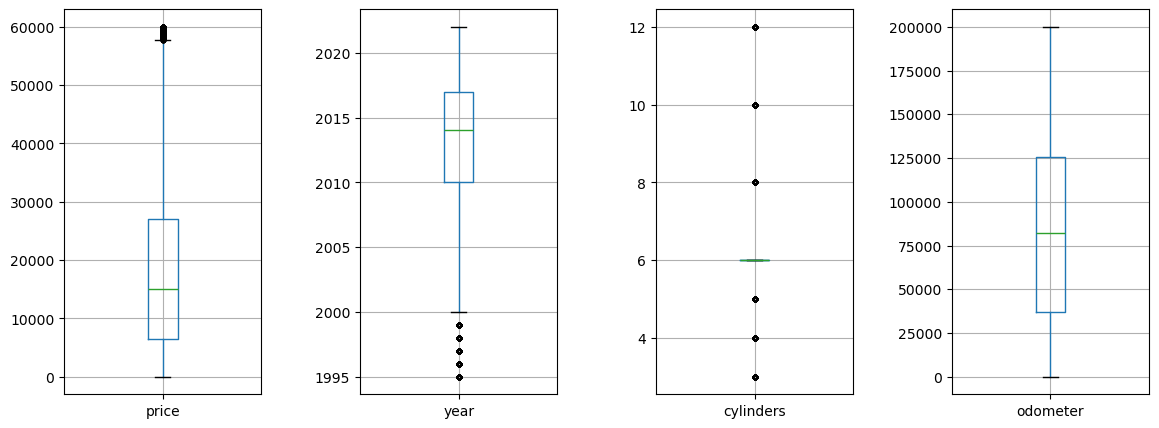

In [355]:
num_cols = car8.select_dtypes(include=['number']).columns
fig, axes = plt.subplots(ncols=4, figsize=(14, 5), sharey=False)

for i in range(0, 4):
  car8.boxplot(num_cols[i], ax=axes[i], flierprops={'markersize':3}) #.boxplot(by=cls, return_type='axes', ax=axes)
    
plt.subplots_adjust(wspace=0.5) 
plt.show()

Let's have a closer look at the cylinders:

<Axes: >

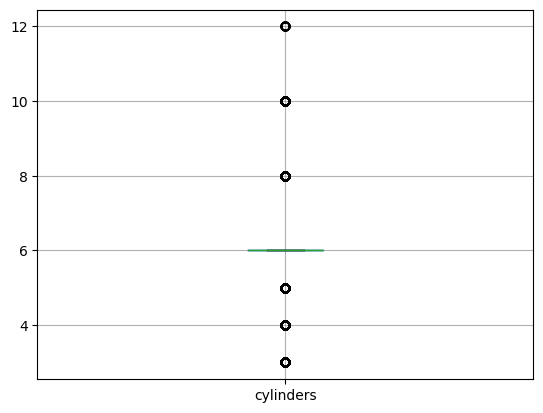

In [356]:
car8.boxplot(['cylinders'])

From the Boxplots above I can see the following:
* price: 75% of the data ranges from around 8000$ to 28000$ with a median price of around 15000$. This supports my assumption that most used cars go no higher than 30000$. But there are still a lot of outliers in the upper range. 
* year: 75% of the data ranges from 2010 to 2017 which also approves of the thought that below 1990 makes not much sense for used cars. There are also some outliers in the lower range but they make complete sense and are reasonable since there are oldtimers.The median is at 2014.
* cylinders: a range from 2 to 12 makes sense since 2 is for very small cars and motorbikes and 12 is for high power sportscars. The Boxplot shows though that 75% and the median are at 6 cylinders.
* odometer (mileage): 75% of the data ranges from 40000 miles to 125000 miles with a median at 80000 miles which also supports my claims that miles above 200000 make not much sense for used cars. 

<Axes: >

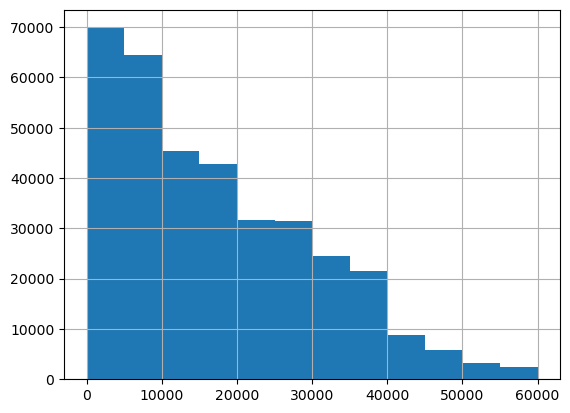

In [357]:
car8.price.hist(bins=12)

This shows that the more expensive the cars are, the less cars there are offered. So there are a lot of cheap cars which is very reasonable since we are talking about used cars. Nobody would want to buy a used car for a ridiculous price unless it is a unique collector's edition etc. 
This once again proves my assumption that the more expensive the cars get, the less significant their numbers are in this dataset. So it was the right decision to remove the super high price values from the dataset.

<Axes: >

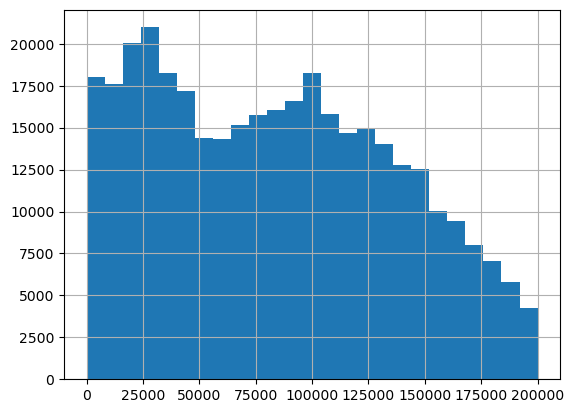

In [358]:
car8.odometer.hist(bins=25)

This Histogram shows that there are less cars with super low mileage and then we have a peak at around 25000 miles and another one at 100000 miles. After 100000 miles, the number of cars listed decrease with the miles increasing. This also shows that it was the right decision to remove the unrealistically high values as it would go close to 0 and with the current data we are explainint a majority of the data. 

<Axes: >

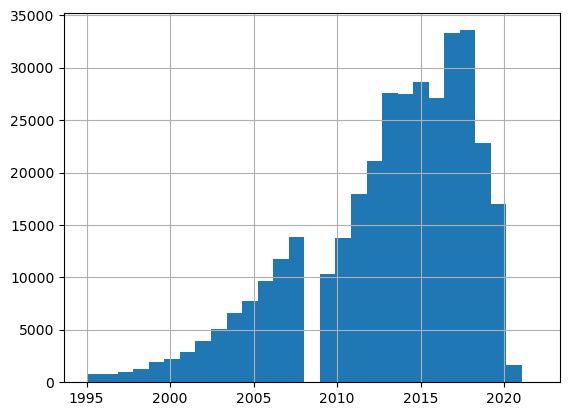

In [359]:
car8.year.hist(bins=29)

<Axes: >

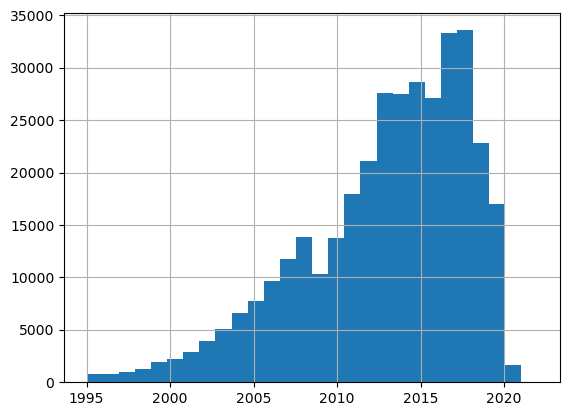

In [360]:
car8.year.hist(bins=28)

The reason why the Histogram seems to have missing data is that year is a continuous variable. If I increase the bins, we will have sections for float numbers of the year which obviously will have nno entries. Because of this, the threshhold for bins is 28. 
This Histogram has an interesting shape. Until year 2008, the number of listed cars is continuously increasing each year. But at year 2009, we have a drop. I wonder why this drop happened and if there is a reason for this. Maybe it was something in the automobile industry that caused less cars to be prodouced. We also have very little cars listed for 2020 which makes a lot of sense because the dataset was gathered in 2021 and this would mean that the cars from 2020 are only 1 year old. 1 year old cars are not really considered used and so people would not sell their cars just yet. According to the histogram, people start selling their cars on Craigslist from aorund 10 after it was produced (they bought it new). Most people sell their cars 8 years after buying it. This is why after 2017, we have a big drop in listed cars because those cars are only 4 years old which is not old for a car at all and it would not make much  sense to be selling a 4 year old car for a regular person.

### Now for the Basic Stats again

In [361]:
car8.describe()

,price,year,cylinders,odometer
count,351964.000000,351964.000000,351964.0,351964.000000
mean,17417.919415,2013.057742,5.930399,84115.490675
std,13450.720530,5.160083,1.19682,52904.981710
min,0.000000,1995.000000,3.0,0.000000
25%,6500.000000,2010.000000,6.0,36766.750000
50%,14988.000000,2014.000000,6.0,81910.000000
75%,26990.000000,2017.000000,6.0,125528.000000
max,59999.000000,2022.000000,12.0,199999.000000


### And for the Correlations

In [362]:
car8[num_cols].corr()

,price,year,cylinders,odometer
price,1.000000,0.493343,0.254123,-0.466067
year,0.493343,1.000000,-0.065495,-0.637287
cylinders,0.254123,-0.065495,1.000000,0.008137
odometer,-0.466067,-0.637287,0.008137,1.000000


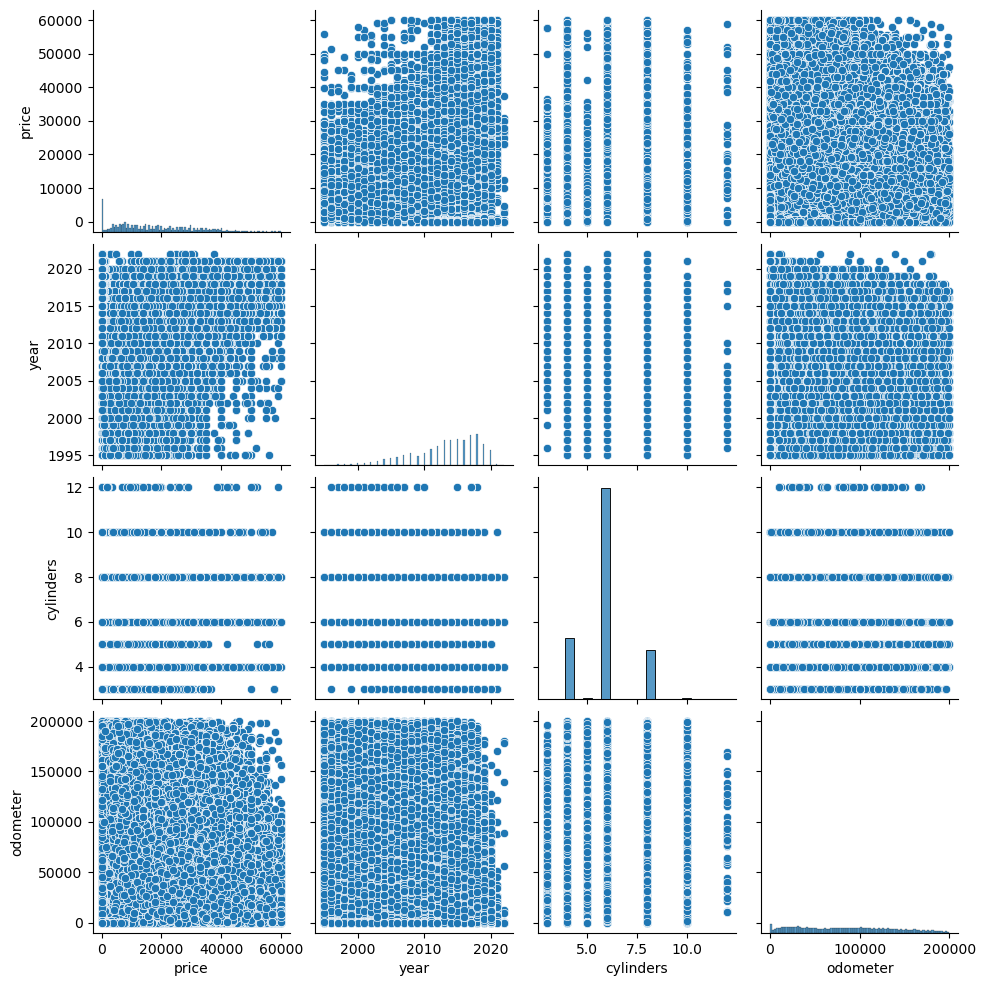

In [363]:
import seaborn as sns
sns.pairplot(data=car8)

From these Correlation Plots, I can not conclude a lot yet, so I will plot them seperately and see what will change

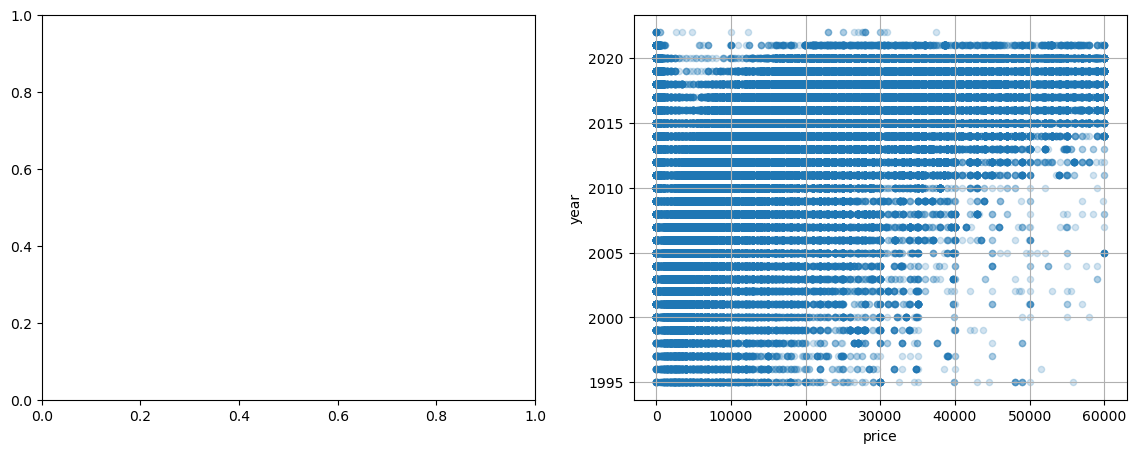

In [364]:
fig, axes = plt.subplots(ncols=2, figsize=(14, 5))

car8.plot(kind="scatter", x="price", y="year", grid=True, alpha = 0.2, ax = axes[1])

plt.show()

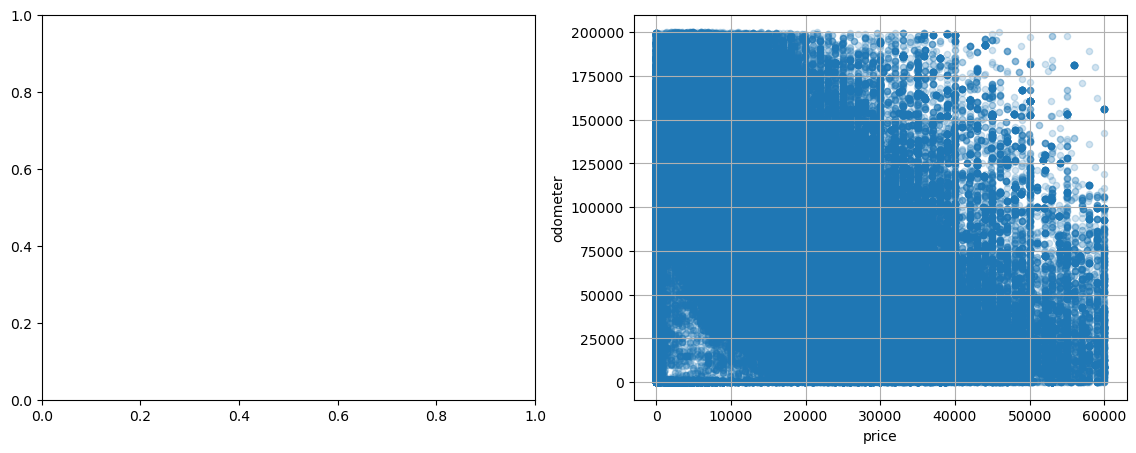

In [365]:
fig, axes = plt.subplots(ncols=2, figsize=(14, 5))

car8.plot(kind="scatter", x="price", y="odometer", grid=True, alpha = 0.2, ax = axes[1])

plt.show()

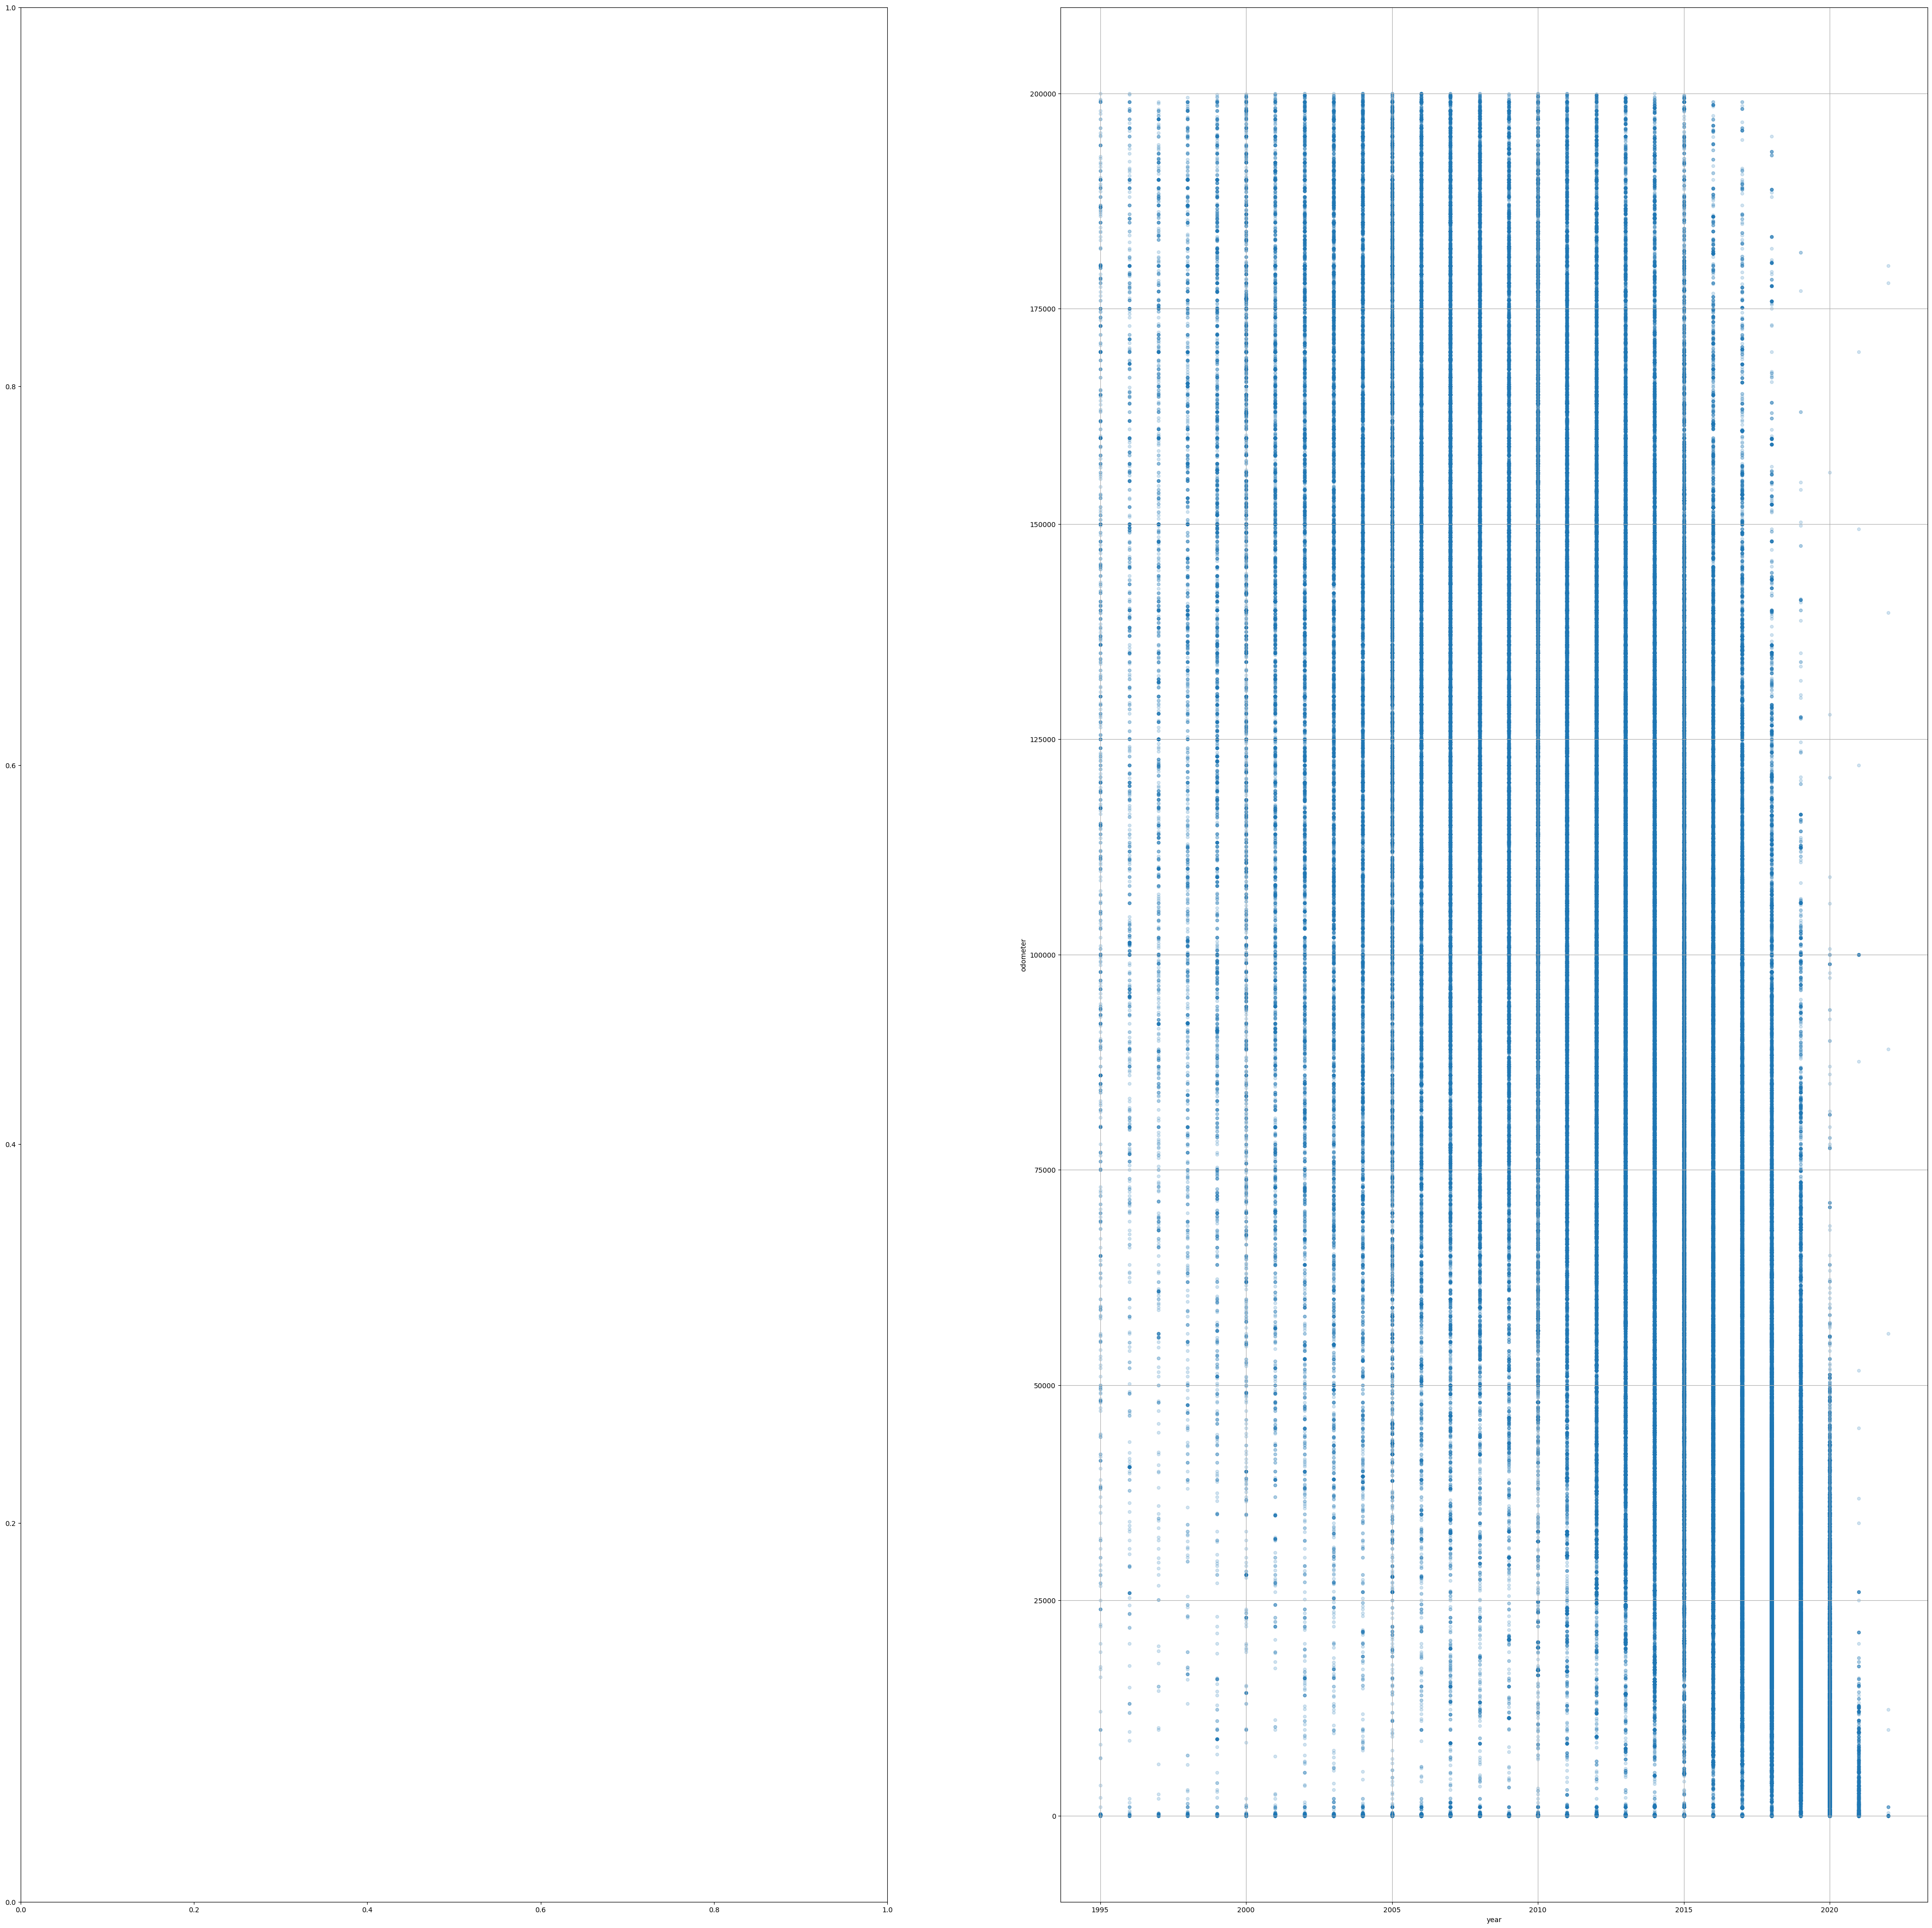

In [366]:
fig, axes = plt.subplots(ncols=2, figsize=(50, 50))

car8.plot(kind="scatter", x="year", y="odometer", grid=True, alpha = 0.2, ax = axes[1])

plt.show()

When increasing the size, the correlation can be a bit more visible, but it is still not a very good showcase.

### Conclusion of Correlation
Since the dataset is too large, it is very hard to see a correlation between the 2 variables. Additionally, the variable year is discrete while price and odometer are continuous. This also messes with the visualization of the data. So, let's focus on the actual numerical correlation values from above. I will paste them here again.

In [367]:
car8[num_cols].corr()

,price,year,cylinders,odometer
price,1.000000,0.493343,0.254123,-0.466067
year,0.493343,1.000000,-0.065495,-0.637287
cylinders,0.254123,-0.065495,1.000000,0.008137
odometer,-0.466067,-0.637287,0.008137,1.000000


I could find the following according to the Correlations:
* the price is increasing as the year increases. This means that the price for used cars increases the newer the car is. This makes logical sense since it would be less used and be closer to the original price.
* The price does not really correlate to the cylinders which is a bit surprising since apparently, more cylinders mean more powerful cars hence more expensive cars like sportscars. So I am a bit surprised by this and I wonder if that might be becuase people do not really sell sportscars on Craigslist? 
* Odometer and cylinders are not linearly related at all.

### Let's plot the price in relation to the year (old cars to new cars)
I will use the mean since there are not really significant outliers because I have removed them previously

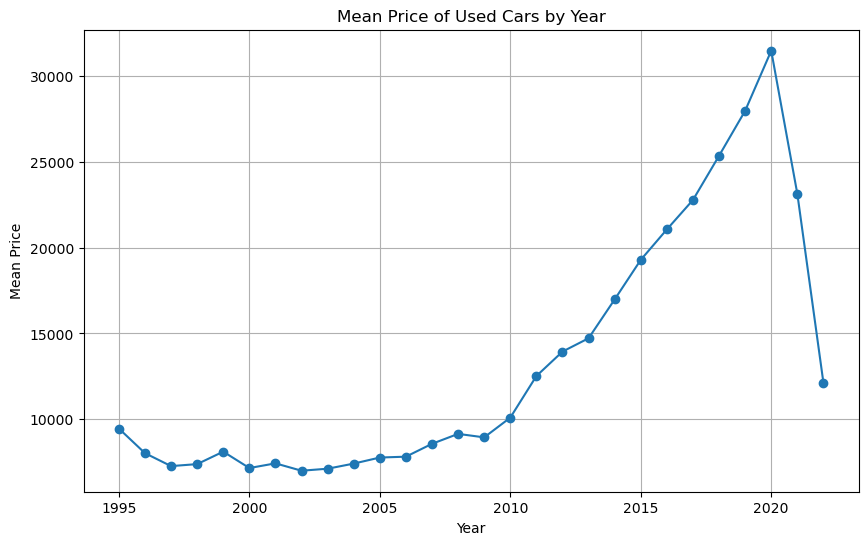

In [374]:
# Create a table with the median price for each year
mean_price_per_year = car8.groupby('year')['price'].mean().reset_index()

# Plot the median price per year
plt.figure(figsize=(10, 6))
plt.plot(mean_price_per_year['year'], mean_price_per_year['price'], marker='o')
plt.xlabel('Year')
plt.ylabel('Mean Price')
plt.title('Mean Price of Used Cars by Year')
plt.grid(True)
plt.show()

This shows, that the price increases as the age of the car decreases. This is very reasonable and logical since the car is more new if the year is higher. This means that the car is approaching its value when it was new. But at the 1995 mark we can see that the line starts increasing. This could be because before 1995, it is very hard to find cars from this age and a lot of collectors might be interested. There, the cars value increases are it is vintage cars. The last 2021 plot can be disregarded as an outlier since it makes no sense for a new car to be less than 5000$.

### Let's plot the price in relation to odometer (mileage) and year
I will also use the mean here since I already cleared outliers previously.

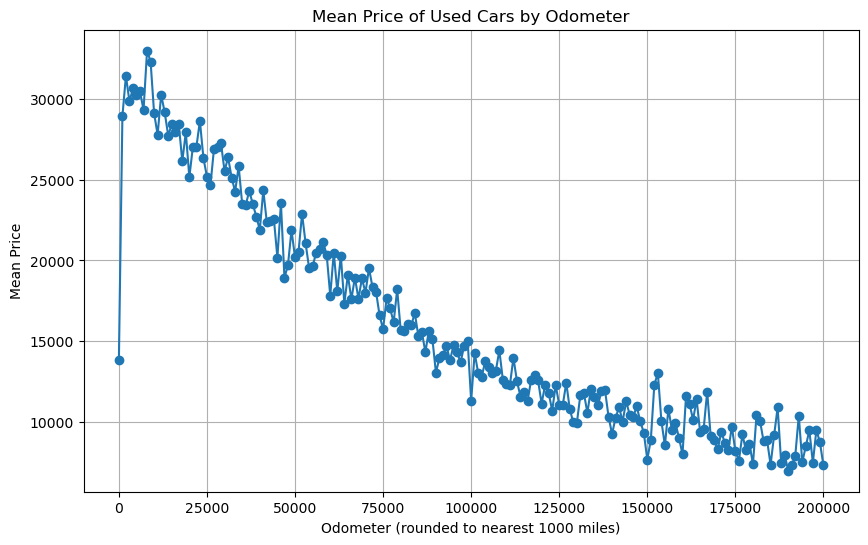

In [375]:
# Create a table with the median price for each odometer value (rounded to nearest 1000 for grouping)
car8['odometer_rounded'] = car8['odometer'].round(-3)
mean_price_per_odometer = car8.groupby('odometer_rounded')['price'].mean().reset_index()

# Plot the median price per odometer
plt.figure(figsize=(10, 6))
plt.plot(mean_price_per_odometer['odometer_rounded'], mean_price_per_odometer['price'], marker='o')
plt.xlabel('Odometer (rounded to nearest 1000 miles)')
plt.ylabel('Mean Price')
plt.title('Mean Price of Used Cars by Odometer')
plt.grid(True)
plt.show()

This graph shows that the price of used cars decreases as the odometer count increases. This is just like the relation of price and year because the older the car is, the more miles it has on its odometer. the first point seems to be an outlier, so it can be disregarded in this context. This means that odometer and year should be linearly related. Lets find this out:

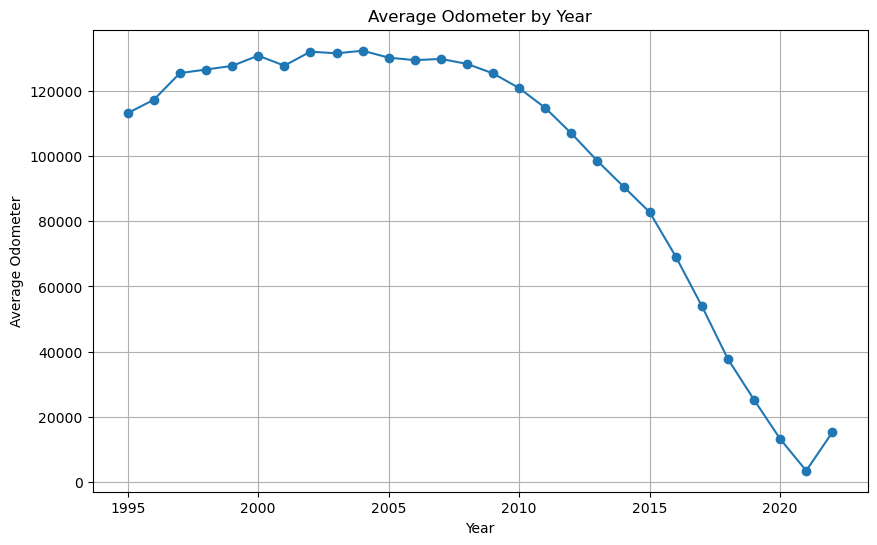

In [373]:
plt.figure(figsize=(10, 6))
plt.plot(mean_odometer_per_year['year'], mean_odometer_per_year['odometer'], marker='o')
plt.xlabel('Year')
plt.ylabel('Average Odometer')
plt.title('Average Odometer by Year')
plt.grid(True)
plt.show()

This graph supports my assumption from above:
The older the car is, the higher the odometer is. At first, the slope rises almost linearly. It then stabilizes. But the interesting part is that past 1998, the odometer starts decreasing the older the car gets. This might be because those old vintage cars stopped being driven at some point becuase they are either too old or people start realizing their worth. Additionally, cars could be getting out of production and people realized that they will be more valuable in the future, so they stopped driving them. This could explain the change in slope.

# Conclusion

This dataset gives information about used cars on Craigslist that are up for sale in the US. The dataset gives insight on mileage, prices, production year, transmission, state, cylinders, etc.. 
I could find out that people on average sell their cars after 8 years (this is assuming that they buy them new). Additionally, odometer (mileage) and year are almost linearly related since older cars had more time to drive more miles. Furthermore, higher mileage descreases the price and newer cars increase the price. Interestingly, I could see a trend of cars before 1995 seem to have lower mileages due to the worth of being vintage and maybe collectors are interested. This analysis supports the intuitive assumptions that were made in the beginning of what increases the price and what does decrese it. 
For the questions: 

* Are cars with higher mileage cheaper?
    -> Yes, cars with higher mileage are cheaper
* Are older cars cheaper than newer ones? 
    -> yes, older cars are cheaper than newer ones apart from vintage, very old cars before 1995
* Are age and mileage of the car related?
    -> Yes, mileage and age are related which follows the intuition. The older the car, the more miles it has since it had more years to be driven. This does not hold for cars before 1995 though probably because of vintage and out of production worth.

## I will save the cleaned dataset into a new file for backup

In [376]:
car8.to_csv('cleaned_vehicles.csv', index=False)